# Import Required Libraries
Import necessary libraries including pandas, numpy, sklearn for model building, and joblib for saving data.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# Load the IRIS Dataset
Load the IRIS dataset from sklearn.datasets using load_iris() function.

In [2]:
# Load the IRIS Dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Dataset loaded successfully!")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Dataset loaded successfully!
Features shape: (150, 4)
Target shape: (150,)


# Explore the Dataset
Display dataset shape, feature names, target names, and basic statistics to understand the data.

In [3]:
# Explore the Dataset
print("Feature Names:", feature_names)
print("\nTarget Names:", target_names)

# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map({i: name for i, name in enumerate(target_names)})

print("\nDataset Shape:", df.shape)
print("\nBasic Statistics:")
df.describe()

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names: ['setosa' 'versicolor' 'virginica']

Dataset Shape: (150, 6)

Basic Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Split Data into Training and Test Sets
Use train_test_split to divide the data into training and test sets with a specified test size and random state.

In [4]:
# Split Data into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 120
Test set size: 30


# Build and Train Classification Model
Create a RandomForestClassifier and fit it on the training data.

In [5]:
# Build and Train Classification Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Model: {model.__class__.__name__}")

Model trained successfully!
Model: RandomForestClassifier


# Make Predictions on Test Set
Use the trained model to predict labels for the test set features.

In [6]:
# Make Predictions on Test Set
y_pred = model.predict(X_test)

print("Predictions completed!")
print(f"Number of predictions: {len(y_pred)}")

Predictions completed!
Number of predictions: 30


# Evaluate Model Performance
Calculate accuracy score, display confusion matrix, and print classification report to evaluate model performance.

In [7]:
# Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9000

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



# Save Test Set with Features, Labels and Predictions
Create a DataFrame containing test features, actual labels, and predicted values, then save it to a CSV file.

In [8]:
# Save Test Set with Features, Labels and Predictions
# Create DataFrame with test features
test_results = pd.DataFrame(X_test, columns=feature_names)

# Add actual labels and predicted values
test_results['actual_label'] = y_test
test_results['actual_species'] = [target_names[i] for i in y_test]
test_results['predicted_label'] = y_pred
test_results['predicted_species'] = [target_names[i] for i in y_pred]

# Save to CSV file
output_path = 'iris_test_results.csv'
test_results.to_csv(output_path, index=False)

print(f"Test results saved to '{output_path}'")
print(f"\nDataFrame shape: {test_results.shape}")
print("\nFirst 10 rows of saved data:")
test_results.head(10)

Test results saved to 'iris_test_results.csv'

DataFrame shape: (30, 8)

First 10 rows of saved data:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_label,actual_species,predicted_label,predicted_species
0,4.4,3.0,1.3,0.2,0,setosa,0,setosa
1,6.1,3.0,4.9,1.8,2,virginica,2,virginica
2,4.9,2.4,3.3,1.0,1,versicolor,1,versicolor
3,5.0,2.3,3.3,1.0,1,versicolor,1,versicolor
4,4.4,3.2,1.3,0.2,0,setosa,0,setosa
5,6.3,3.3,4.7,1.6,1,versicolor,1,versicolor
6,4.6,3.6,1.0,0.2,0,setosa,0,setosa
7,5.4,3.4,1.7,0.2,0,setosa,0,setosa
8,6.5,3.0,5.2,2.0,2,virginica,2,virginica
9,5.4,3.0,4.5,1.5,1,versicolor,1,versicolor


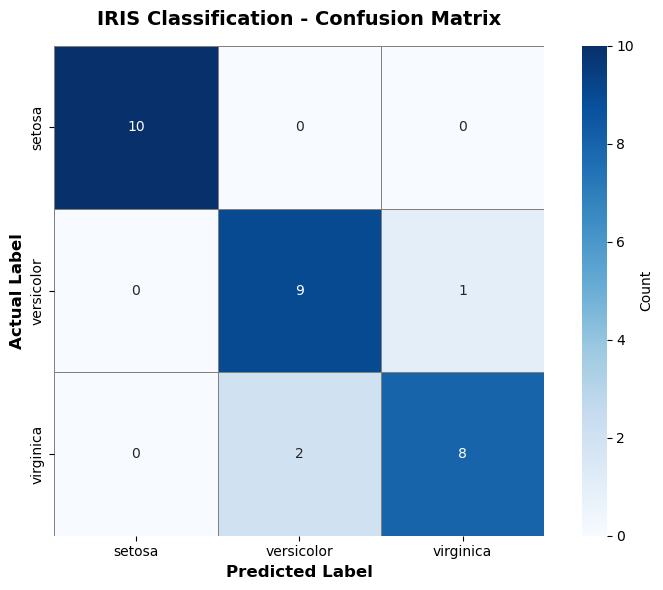

In [9]:
# Confusion Matrix Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            square=True, linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'}, ax=ax)

# Formatting
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
ax.set_title('IRIS Classification - Confusion Matrix', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

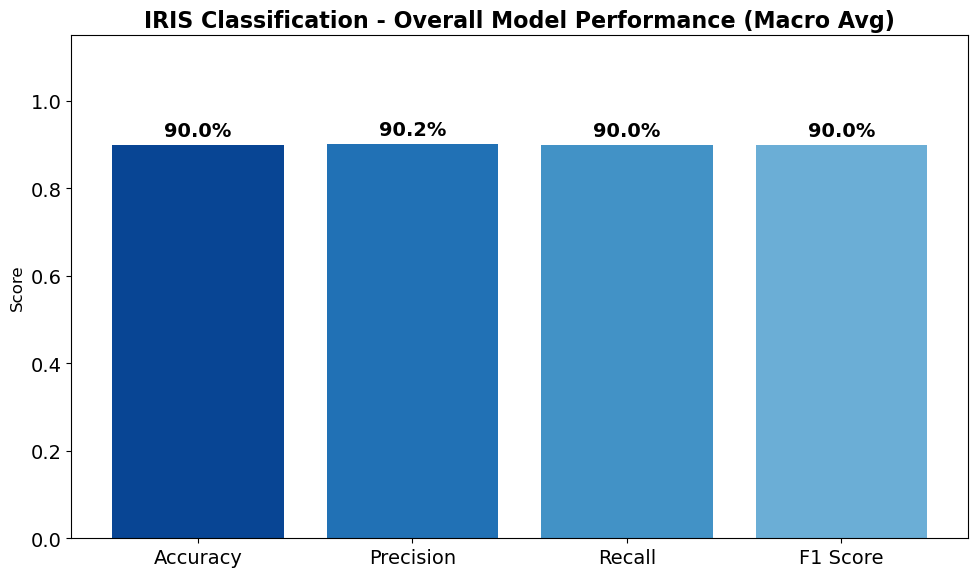

In [10]:
# Classification Report with Bar Plot Visualization
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1. Calculate Metrics
report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)

# Extract the specific overall metrics
metrics = {
    'Accuracy': report['accuracy'],
    'Precision': report['macro avg']['precision'],
    'Recall': report['macro avg']['recall'],
    'F1 Score': report['macro avg']['f1-score']
}

# 2. Prepare Plot
names = list(metrics.keys())
values = list(metrics.values())

# Set font size
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create Bar Plot with Blue colors
colors = ['#084594', '#2171b5', '#4292c6', '#6baed6']
bars = ax.bar(names, values, color=colors)

# 4. Add labels and formatting
ax.set_title('IRIS Classification - Overall Model Performance (Macro Avg)', fontsize=16, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)

# Add percentage text labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.1%}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Class-wise Metrics:
     Class  Precision  Recall  F1-Score  Support
    setosa   1.000000     1.0  1.000000     10.0
versicolor   0.818182     0.9  0.857143     10.0
 virginica   0.888889     0.8  0.842105     10.0


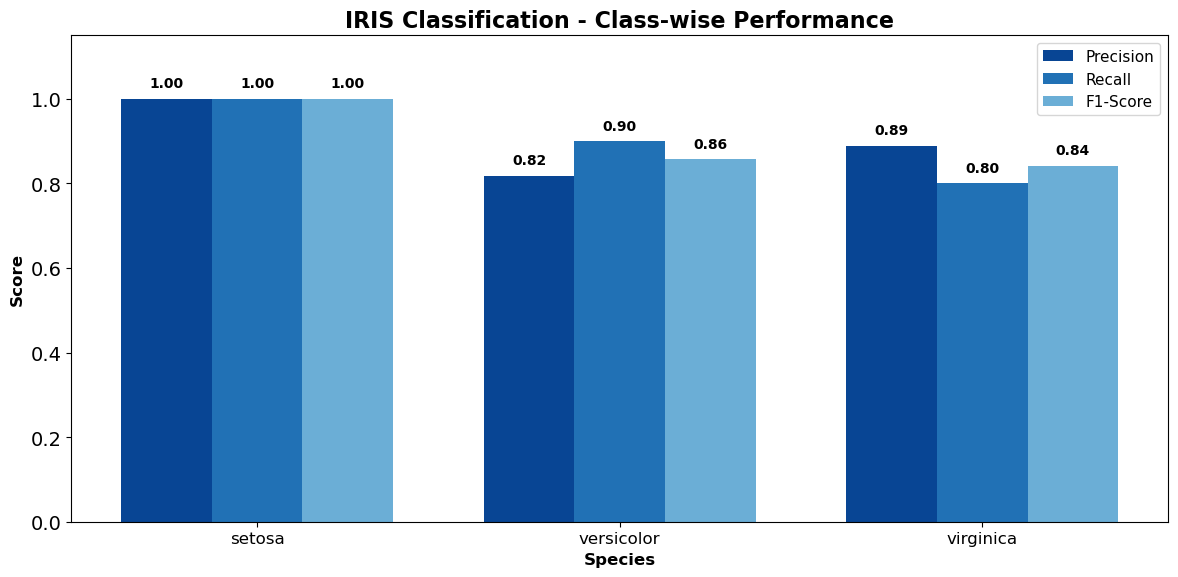

In [11]:
# Class-wise Precision, Recall and F1-Score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# 1. Calculate Metrics
report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)

# Extract class-wise metrics
classes = list(target_names)
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]
support = [report[cls]['support'] for cls in classes]

# 2. Display as DataFrame
class_metrics_df = pd.DataFrame({
    'Class': classes,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score,
    'Support': support
})
print("Class-wise Metrics:")
print(class_metrics_df.to_string(index=False))

# 3. Create Grouped Bar Plot
x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

# Create grouped bars
bars1 = ax.bar(x - width, precision, width, label='Precision', color='#084594')
bars2 = ax.bar(x, recall, width, label='Recall', color='#2171b5')
bars3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#6baed6')

# Add labels and formatting
ax.set_xlabel('Species', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('IRIS Classification - Class-wise Performance', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=11)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()